In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Linear Regression from Scratch with NumPy
Linear regression trained with gradient descent, implemented from scratch
(no machine learning libraries), applied to Yemen's foreign investment
and unemployment data (1990–2000).

In [2]:
import numpy as np
x_train=np.array([-1.03,1.92,3.99,4.15,0.05,-1.7,0.92,-2.02,-3.47,-4.02,-0.06])
y_train=np.array([8.18,8.13,8.34,8.34,8.98,9.58,10.22,10.83,11.46,11.56,11.72])
a_train=np.array([1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000])

In [1]:

def model_function(x,w,b):
    y=w*x+b
    return y
def cost_function(x,y,w,b):
    m=len(x)
    cost=0
    for i in range(m):
        prediction=model_function(x[i],w,b)
        error=prediction-y[i]
        error_squared=error**2
        cost=cost+error_squared
    total_cost=cost/(2*m)
    return total_cost
def compute_descent(x,y,w,b):
    dw=0
    db=0
    m=len(x)
    for i in range(m):
        prediction=model_function(x[i],w,b)
        error=prediction-y[i]
        erx=error*x[i]
        dw=dw+erx
        db=db+error
    total_dw=dw/m
    total_db=db/m
    return total_dw,total_db

In [4]:
num_iters=1000
threshold=0.000000001
previous_cost=100
b=0
w=0
alpha=0.1
for i in range(num_iters):
    dw,db=compute_descent(x_train,y_train,w,b)
    w=w-alpha*dw
    b=b-alpha*db
    current_cost=cost_function(x_train,y_train,w,b)
    improvement=previous_cost-current_cost
    previous_cost=current_cost
    if improvement<threshold:
        break
print(w,b,current_cost)

-0.3766869825992815 9.714599349496911 0.48581696785386175


Mine:   -0.3766869825992815 9.714599349496911
Check:  -0.3766851169436349 9.714691809225595


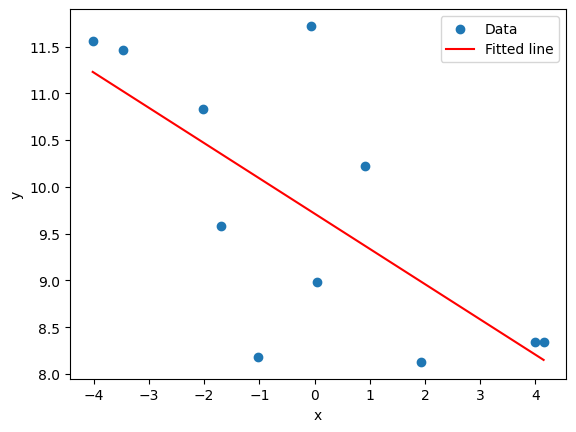

In [5]:
import matplotlib.pyplot as plt

# Check against NumPy's built-in least squares fit
w_ref, b_ref = np.polyfit(x_train, y_train, 1)
print("Mine:  ", w, b)
print("Check: ", w_ref, b_ref)

# Plot data and fitted line
plt.scatter(x_train, y_train, label="Data")
x_line = np.linspace(x_train.min(), x_train.max(), 100)
plt.plot(x_line, w * x_line + b, color="red", label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()